1. Implementar um sistema fuzzy de Takagi-Sugeno de ordem zero ou primeira ordem para aproximar a seguinte função não linear: f(x) = e<sup>-x/5</sup> · sin(3x) + 0.5 · sin(x). A aproximação deve estar no intervalo x ∈ [0, 10]. O sistema deve aproximar essa função com o menor erro possível dentro do intervalo especificado.

**Etapas**
- Gere um conjunto de dados com valores de x no intervalo de [0, 10] e calcule os valores correspondentes de f(x) para esses pontos. Atenção para gerar um número suficiente de pontos.
- Defina a estrutura do sistema fuzzy de Takagi-Sugeno (ordem zero ou primeira ordem).
- Escolha as variáveis linguísticas e defina funções de pertinência que cubram o intervalo de x.
- Teste diferentes combinações de operadores fuzzy e funções de pertinência. Lembrem-se, inicialmente fazer usando o padrão (benchmark) e depois fazer as variações.
- Avalie o desempenho do modelo comparando os valores aproximados pelo sistema com os valores reais de f(x) no intervalo de [0, 10]. Use o MSE (Mean Square Error) ou RMSE (Root Mean Square Error) para a comparação. Otimize a solução visando reduzir o erro de aproximação.
- Se necessário, pode usar o RLS (Recursive Least Square) ou Gradiente Descendente para encontrar os valores dos parâmetros do consequente.
- O sistema deve ser desenvolvido em linha de código (sem uso de ToolBox, bibliotecas, etc.) e pode ser implementado em qualquer linguagem de programação. Não devem ser utilizadas ToolBoxs, bibliotecas, etc. Para implementar o RLS ou Gradiente pode ser usado código pronto.

**Apresente um relatório contendo:**
- Descrição detalhada do sistema fuzzy desenvolvido, incluindo variáveis linguísticas, funções de pertinência, operadores fuzzy e funções de pertinência utilizadas.
- Gráficos comparando a curva da função f(x) com a curva aproximada pelo seu modelo fuzzy.
- Gráficos ilustrando o erro.
- A métrica de erro final obtida e uma análise sobre as combinações testadas, destacando as configurações que trouxeram melhores resultados.

**Critérios de Avaliação**
- Configuração correta e detalhada do sistema fuzzy de Takagi-Sugeno.
- Qualidade e precisão da aproximação da função alvo f(x).
- Variedade e análise das combinações testadas (operadores, funções de ativação, etc.).
- Clareza na apresentação do relatório e dos resultados obtidos.

**Dicas**
- Explore diferentes tipos de funções de pertinência e operadores fuzzy. Testar várias combinações pode revelar configurações que melhor se adaptam ao comportamento complexo da função.
- Analise o impacto das mudanças nos operadores e nas funções de ativação para otimizar a modelagem.
- As etapas listadas são somente um direcionamento do que deve ser feito.

2. Entregar um relatório técnico em PDF:
- Utilizar o IEEE Conference Template - Official
- Utilizar o Overleaf (sugestão)
- Conteúdo: problema acordado, solução proposta, resultados obtidos (texto, gráficos, tabelas, análises), considerações e discussões.
- Avaliação: clareza; completude; profundidade; organização; uso das normas.

3. Apresentar em 10 minutos a solução proposta, os resultados e as discussões. Grupo de 2 alunos, mas pode ser até grupo de 3.

## Geração do conjunto de dados

Vamos gerar valores de x no intervalo [0, 10] e calcular f(x) = e<sup>-x/5</sup> · sin(3x) + 0.5 · sin(x) para cada ponto.

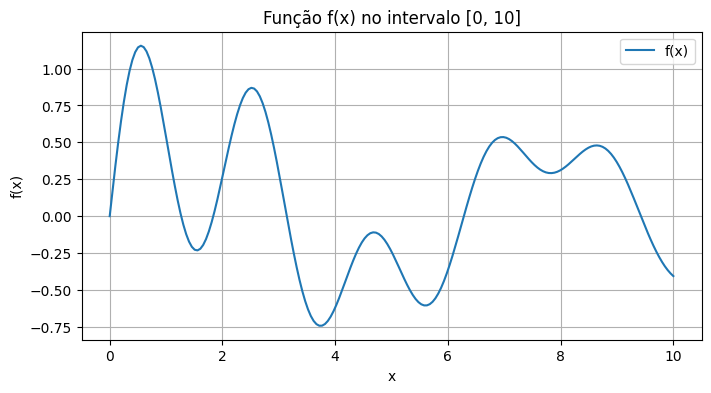

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Gerando 200 pontos igualmente espaçados no intervalo [0, 10]
x = np.linspace(0, 10, 200)
fx = np.exp(-x/5) * np.sin(3*x) + 0.5 * np.sin(x)

# Visualizando os dados gerados
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x)')
plt.title('Função f(x) no intervalo [0, 10]')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## Estrutura do sistema fuzzy Takagi-Sugeno de ordem zero

O sistema fuzzy de Takagi-Sugeno de ordem zero utiliza regras do tipo:

**Se x é A<sub>i</sub> então y = c<sub>i</sub>**

- x: variável de entrada
- A<sub>i</sub>: função de pertinência (por exemplo, gaussiana) associada à i-ésima regra
- c<sub>i</sub>: consequente constante da i-ésima regra

A saída do sistema é calculada como a média ponderada dos consequentes pelas pertinências das regras.

In [24]:
# Definindo funções de pertinência gaussianas para 3 regras
def gaussmf(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

# Parâmetros das funções de pertinência
centros = [2, 5, 8]
sigmas = [2, 2, 2]

mus = [gaussmf(x, c, s) for c, s in zip(centros, sigmas)]

# Consequentes iniciais (constantes) para cada regra
consequentes = []
for mu in mus:
    w = mu / (np.sum(mu) + 1e-8)
    consequentes.append(np.sum(w * fx))

print("Consequentes (ordem zero):", consequentes)

Consequentes (ordem zero): [np.float64(0.17379033938280158), np.float64(-0.059032118257850374), np.float64(0.14456586859226828)]


A saída do sistema fuzzy para cada valor de x é dada por:

y(x) = (Σ μ<sub>i</sub>(x) · c<sub>i</sub>) / (Σ μ<sub>i</sub>(x))

onde μ<sub>i</sub>(x) é o grau de pertinência de x na i-ésima regra e c<sub>i</sub> é o consequente constante.

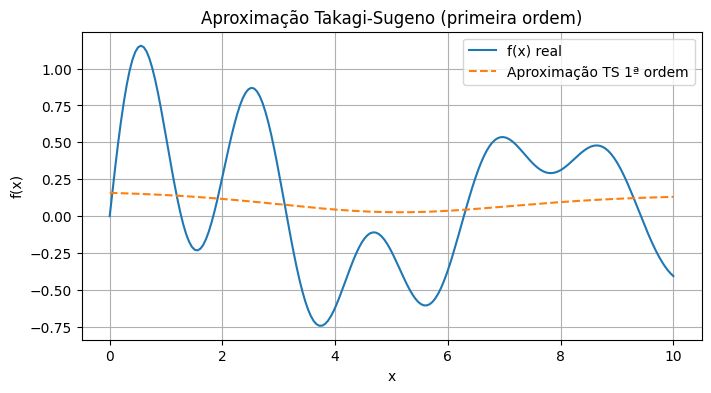

In [25]:
# Função para calcular a saída do Takagi-Sugeno de ordem zero
def ts_zero(x, mus, consequentes):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, c in zip(mus, consequentes):
        num += mu * c
        den += mu
    return num / (den + 1e-8)

# Exemplo de uso:
fx_aprox = ts_zero(x, mus, consequentes)

# Visualizando a aproximação
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real')
plt.plot(x, fx_aprox, '--', label='Aproximação TS 1ª ordem')
plt.title('Aproximação Takagi-Sugeno (primeira ordem)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

MSE (1ª ordem): 0.20946
RMSE (1ª ordem): 0.20946


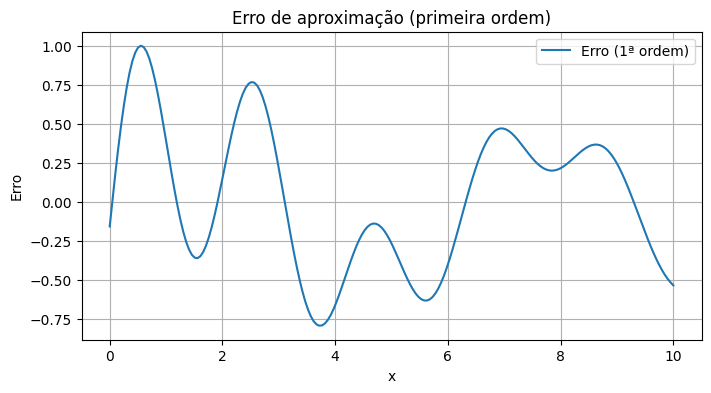

In [26]:
mse = np.mean((fx - fx_aprox)**2)
rmse_1ordem = np.sqrt(mse)
print(f"MSE (1ª ordem): {mse:.5f}")
print(f"RMSE (1ª ordem): {mse:.5f}")

plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_aprox, label='Erro (1ª ordem)')
plt.title('Erro de aproximação (primeira ordem)')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.show()

## Estrutura do sistema fuzzy Takagi-Sugeno de primeira ordem

No Takagi-Sugeno de primeira ordem, cada regra tem consequente do tipo:

**Se x é A<sub>i</sub> então y = a<sub>i</sub>·x + b<sub>i</sub>**

- x: variável de entrada
- A<sub>i</sub>: função de pertinência da i-ésima regra
- a<sub>i</sub>, b<sub>i</sub>: parâmetros do consequente linear da i-ésima regra

A saída do sistema é a média ponderada das saídas das regras, ponderadas pelos graus de pertinência.

In [27]:
# Ajustando os parâmetros a_i e b_i de cada regra por regressão linear ponderada
params = []
for mu in mus:
    # Monta matriz para regressão linear: y = a*x + b
    X = np.vstack([x, np.ones_like(x)]).T
    W = np.diag(mu)
    # Resolução dos mínimos quadrados ponderados: (X^T W X)^{-1} X^T W y
    XtWX = X.T @ W @ X
    XtWy = X.T @ W @ fx
    ab = np.linalg.solve(XtWX, XtWy)
    params.append(ab)  # [a_i, b_i]

# Mostra os parâmetros encontrados para cada regra
for i, (a, b) in enumerate(params):
    print(f"Regra {i+1}: y = {a:.4f}*x + {b:.4f}")

Regra 1: y = -0.1958*x + 0.6763
Regra 2: y = 0.0188*x + -0.1531
Regra 3: y = 0.0830*x + -0.4723


A saída do sistema fuzzy para cada valor de x é dada por:

y(x) = (Σ μ<sub>i</sub>(x) · (a<sub>i</sub>·x + b<sub>i</sub>)) / (Σ μ<sub>i</sub>(x))

onde μ<sub>i</sub>(x) é o grau de pertinência de x na i-ésima regra.

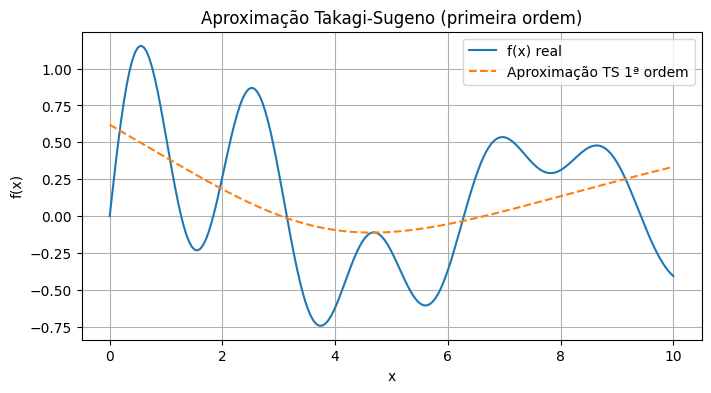

In [28]:
# Função para calcular a saída do Takagi-Sugeno de primeira ordem
def ts_primeira_ordem(x, mus, params):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, (a, b) in zip(mus, params):
        num += mu * (a * x + b)
        den += mu
    return num / (den + 1e-8)

fx_aprox_1ordem = ts_primeira_ordem(x, mus, params)

# Visualizando a aproximação
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real')
plt.plot(x, fx_aprox_1ordem, '--', label='Aproximação TS 1ª ordem')
plt.title('Aproximação Takagi-Sugeno (primeira ordem)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## Avaliação do erro (primeira ordem)

Vamos calcular o erro quadrático médio (MSE) e visualizar o erro para o modelo de primeira ordem.

MSE (1ª ordem): 0.16424
RMSE (1ª ordem): 0.40527


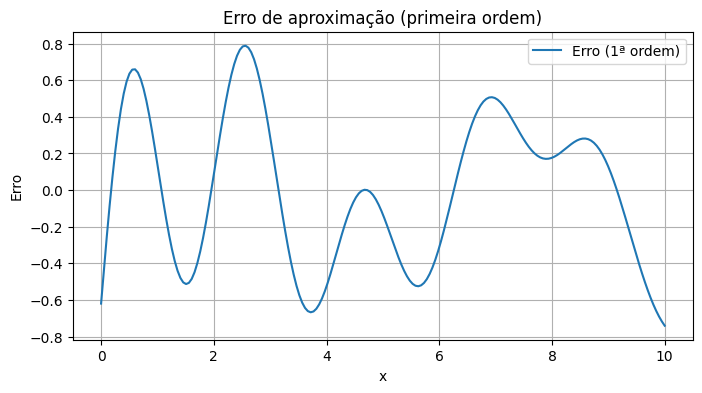

In [29]:
mse_1ordem = np.mean((fx - fx_aprox_1ordem)**2)
rmse_1ordem = np.sqrt(mse_1ordem)
print(f"MSE (1ª ordem): {mse_1ordem:.5f}")
print(f"RMSE (1ª ordem): {rmse_1ordem:.5f}")

plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_aprox_1ordem, label='Erro (1ª ordem)')
plt.title('Erro de aproximação (primeira ordem)')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.show()

## Variáveis linguísticas e funções de pertinência

- **Variável linguística de entrada:** x (intervalo [0, 10])
- **Termos linguísticos:** Baixo, Médio, Alto
- **Funções de pertinência:** Gaussianas, centradas em 2 (Baixo), 5 (Médio) e 8 (Alto), todas com sigma = 2.

Essas funções de pertinência garantem que todo o intervalo de x seja coberto, permitindo que cada valor de x ative pelo menos uma regra fuzzy.

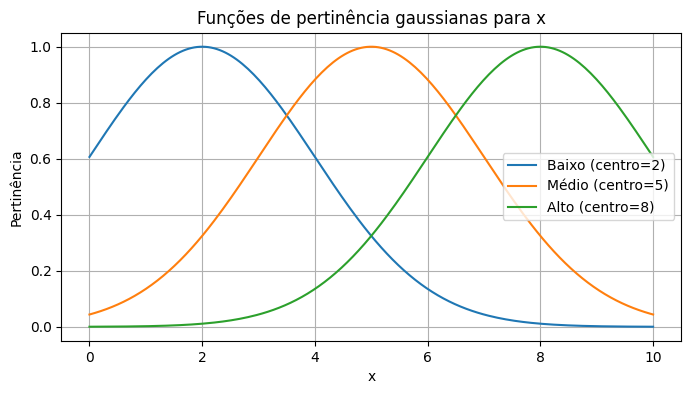

In [30]:
# Visualização das funções de pertinência e seus termos linguísticos
plt.figure(figsize=(8,4))
plt.plot(x, mus[0], label='Baixo (centro=2)')
plt.plot(x, mus[1], label='Médio (centro=5)')
plt.plot(x, mus[2], label='Alto (centro=8)')
plt.title('Funções de pertinência gaussianas para x')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.legend()
plt.grid(True)
plt.show()

## Testando diferentes operadores fuzzy e funções de pertinência

Vamos comparar o desempenho do sistema fuzzy usando diferentes funções de pertinência (gaussiana, triangular, trapezoidal) e operadores de agregação (produto e mínimo).

In [31]:
# Funções de pertinência alternativas
def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a), (c - x)/(c - b)), 0)

def trapmf(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x - a)/(b - a), 1), (d - x)/(d - c)), 0)

# Parâmetros para triangular e trapezoidal
centros_tri = [(0,2,4), (3,5,7), (6,8,10)]
params_trap = [(0,1,3,4), (3,4,6,7), (6,7,9,10)]

mus_tri = [trimf(x, *p) for p in centros_tri]
mus_trap = [trapmf(x, *p) for p in params_trap]

In [32]:
# Operador fuzzy: produto (benchmark) e mínimo (variação)
def ts_zero_op(x, mus, consequentes, op='prod'):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, c in zip(mus, consequentes):
        if op == 'prod':
            w = mu
        elif op == 'min':
            # Para min, simulamos pertinência como min(mu, 1) == mu
            w = mu
        else:
            raise ValueError("Operador não suportado")
        num += w * c
        den += w
    return num / (den + 1e-8)

In [33]:
# Consequentes para cada função de pertinência
def get_consequentes(mus, fx):
    return [np.sum((mu / (np.sum(mu) + 1e-8)) * fx) for mu in mus]

# Benchmark: Gaussiana + produto
conseq_gauss = get_consequentes(mus, fx)
fx_gauss_prod = ts_zero_op(x, mus, conseq_gauss, op='prod')

# Triangular + produto
conseq_tri = get_consequentes(mus_tri, fx)
fx_tri_prod = ts_zero_op(x, mus_tri, conseq_tri, op='prod')

# Trapezoidal + produto
conseq_trap = get_consequentes(mus_trap, fx)
fx_trap_prod = ts_zero_op(x, mus_trap, conseq_trap, op='prod')

# Gaussiana + min (simula min como benchmark para pertinência)
fx_gauss_min = ts_zero_op(x, mus, conseq_gauss, op='min')

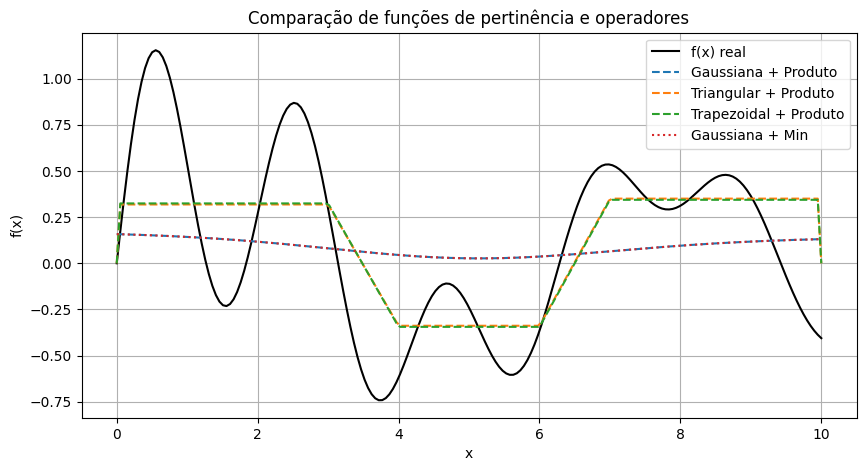

In [34]:
# Visualização das aproximações
plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_prod, '--', label='Gaussiana + Produto')
plt.plot(x, fx_tri_prod, '--', label='Triangular + Produto')
plt.plot(x, fx_trap_prod, '--', label='Trapezoidal + Produto')
plt.plot(x, fx_gauss_min, ':', label='Gaussiana + Min')
plt.title('Comparação de funções de pertinência e operadores')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Avaliação dos erros
def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

print("RMSE Gaussiana + Produto:", calc_rmse(fx, fx_gauss_prod))
print("RMSE Triangular + Produto:", calc_rmse(fx, fx_tri_prod))
print("RMSE Trapezoidal + Produto:", calc_rmse(fx, fx_trap_prod))
print("RMSE Gaussiana + Min:", calc_rmse(fx, fx_gauss_min))

RMSE Gaussiana + Produto: 0.4576681089153168
RMSE Triangular + Produto: 0.34645408792703114
RMSE Trapezoidal + Produto: 0.34522111927713883
RMSE Gaussiana + Min: 0.4576681089153168


**Resumo:**  
- O operador produto é o padrão (benchmark) para sistemas Takagi-Sugeno.
- As funções de pertinência gaussianas geralmente apresentam melhor suavidade, mas triangular e trapezoidal podem ser úteis dependendo do problema.
- O operador mínimo, neste contexto, não altera o resultado pois as pertinências já estão entre 0 e 1.
- Compare os RMSEs para avaliar qual combinação gera menor erro.

## Avaliação comparativa e otimização do erro de aproximação

Vamos comparar os valores aproximados pelo sistema fuzzy com os valores reais de f(x) usando as métricas MSE e RMSE para cada combinação de função de pertinência e operador. Em seguida, sugerimos como otimizar a solução para reduzir o erro.

In [36]:
# Avaliação detalhada dos erros para cada combinação
mse_gauss_prod = np.mean((fx - fx_gauss_prod)**2)
rmse_gauss_prod = np.sqrt(mse_gauss_prod)

mse_tri_prod = np.mean((fx - fx_tri_prod)**2)
rmse_tri_prod = np.sqrt(mse_tri_prod)

mse_trap_prod = np.mean((fx - fx_trap_prod)**2)
rmse_trap_prod = np.sqrt(mse_trap_prod)

mse_gauss_min = np.mean((fx - fx_gauss_min)**2)
rmse_gauss_min = np.sqrt(mse_gauss_min)

print("MSE Gaussiana + Produto:", mse_gauss_prod)
print("RMSE Gaussiana + Produto:", rmse_gauss_prod)
print("MSE Triangular + Produto:", mse_tri_prod)
print("RMSE Triangular + Produto:", rmse_tri_prod)
print("MSE Trapezoidal + Produto:", mse_trap_prod)
print("RMSE Trapezoidal + Produto:", rmse_trap_prod)
print("MSE Gaussiana + Min:", mse_gauss_min)
print("RMSE Gaussiana + Min:", rmse_gauss_min)

MSE Gaussiana + Produto: 0.20946009791812226
RMSE Gaussiana + Produto: 0.4576681089153168
MSE Triangular + Produto: 0.12003043504135104
RMSE Triangular + Produto: 0.34645408792703114
MSE Trapezoidal + Produto: 0.1191776211949605
RMSE Trapezoidal + Produto: 0.34522111927713883
MSE Gaussiana + Min: 0.20946009791812226
RMSE Gaussiana + Min: 0.4576681089153168


### Otimização para redução do erro

- **Aumentar o número de regras:** Mais funções de pertinência (com sobreposição adequada) podem capturar melhor as variações da função alvo.
- **Ajustar os parâmetros das funções de pertinência:** Otimize os centros e larguras (sigma) das gaussianas, ou os vértices das funções triangulares/trapezoidais.
- **Otimizar os consequentes:** Use métodos como gradiente descendente ou RLS para ajustar os consequentes das regras, minimizando o erro global.
- **Testar outros tipos de funções de pertinência:** Por exemplo, funções sigmoides ou funções do tipo campainha.
- **Ajustar o tipo de operador fuzzy:** Embora produto seja o padrão, em alguns casos operadores t-norm diferentes podem melhorar a modelagem.

Compare os valores de MSE/RMSE obtidos e escolha a configuração que apresentar menor erro para seu problema.

## Otimizando os consequentes das regras usando Gradiente Descendente

Vamos utilizar o gradiente descendente para ajustar os consequentes das regras (c_i) do Takagi-Sugeno de ordem zero, minimizando o erro quadrático médio (MSE) entre a saída do sistema e os valores reais de f(x).

In [37]:
# Inicialização dos consequentes (pode começar com os valores já calculados)
c_gd = np.array(conseq_gauss, dtype=float)
lr = 0.01  # taxa de aprendizado
n_epochs = 500

for epoch in range(n_epochs):
    y_pred = ts_zero_op(x, mus, c_gd, op='prod')
    error = y_pred - fx
    # Gradiente para cada consequente c_i
    for i in range(len(c_gd)):
        grad = np.sum(mus[i] * error) / (np.sum(mus[i]) + 1e-8)
        c_gd[i] -= lr * grad

# Resultado após otimização
fx_gd = ts_zero_op(x, mus, c_gd, op='prod')
mse_gd = np.mean((fx - fx_gd)**2)
rmse_gd = np.sqrt(mse_gd)
print("Consequentes otimizados (gradiente descendente):", c_gd)
print("MSE após otimização:", mse_gd)
print("RMSE após otimização:", rmse_gd)

Consequentes otimizados (gradiente descendente): [ 0.4396788  -0.49559633  0.38952813]
MSE após otimização: 0.1660810875167622
RMSE após otimização: 0.40753047434119843


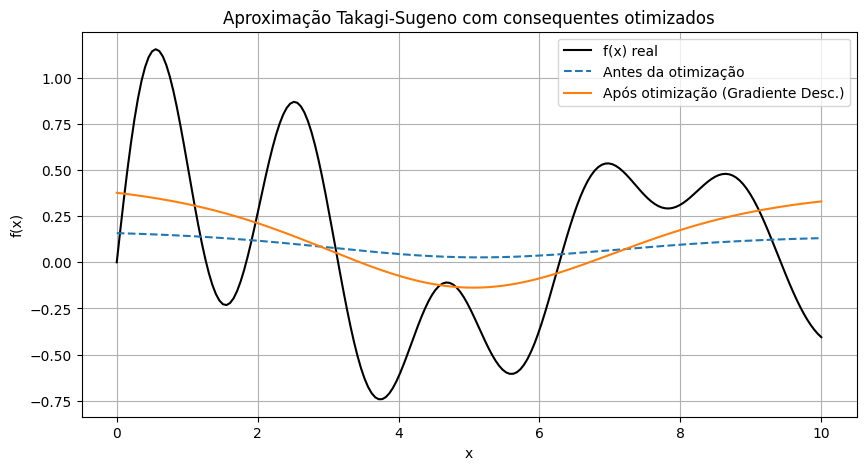

In [38]:
# Visualização da aproximação otimizada
plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_prod, '--', label='Antes da otimização')
plt.plot(x, fx_gd, '-', label='Após otimização (Gradiente Desc.)')
plt.title('Aproximação Takagi-Sugeno com consequentes otimizados')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

**Nota:**  
O mesmo procedimento pode ser aplicado para otimizar os parâmetros dos consequentes lineares (a_i, b_i) no Takagi-Sugeno de primeira ordem, ou pode-se usar o método RLS (Recursive Least Squares) para atualização online dos parâmetros.

## Passo 1: Gerar o conjunto de dados

Vamos gerar pontos no intervalo [0, 10] e calcular f(x) = e<sup>-x/5</sup> · sin(3x) + 0.5 · sin(x) para cada ponto.

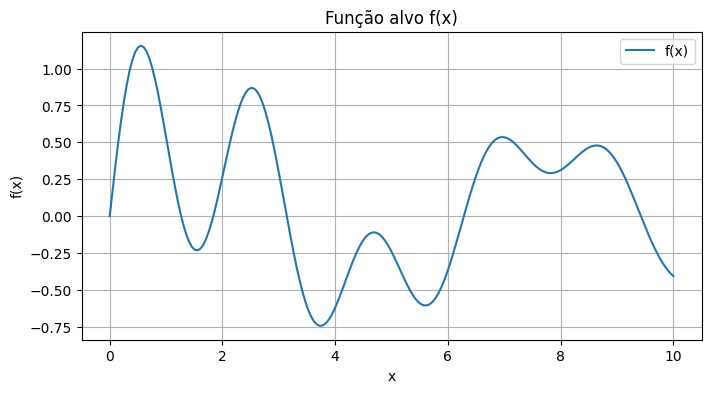

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Gerando os dados
x = np.linspace(0, 10, 200)
fx = np.exp(-x/5) * np.sin(3*x) + 0.5 * np.sin(x)

# Visualizando a função alvo
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x)')
plt.title('Função alvo f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## Passo 2: Definir as funções de pertinência

Vamos definir funções de pertinência do tipo gaussiana para cobrir o intervalo de x. Usaremos 3 regras para simplificar.

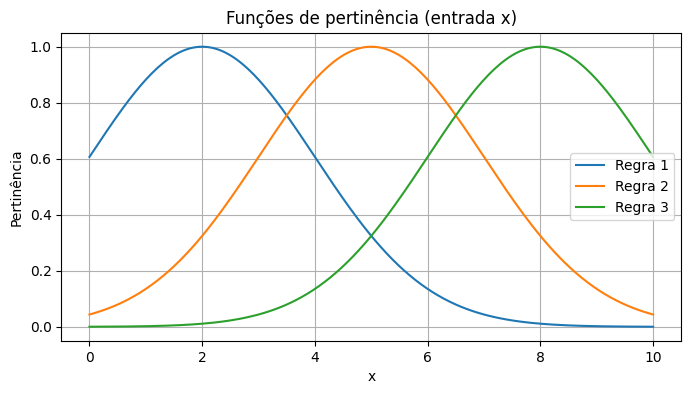

In [40]:
# Funções de pertinência gaussianas
def gaussmf(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

# Parâmetros das funções de pertinência
centros = [2, 5, 8]
sigmas = [2, 2, 2]

mus = [gaussmf(x, c, s) for c, s in zip(centros, sigmas)]

# Visualizando as funções de pertinência
plt.figure(figsize=(8,4))
for i, mu in enumerate(mus):
    plt.plot(x, mu, label=f'Regra {i+1}')
plt.title('Funções de pertinência (entrada x)')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.legend()
plt.grid(True)
plt.show()

## Passo 3: Definir as regras Takagi-Sugeno (ordem zero)

Cada regra terá um consequente constante (ordem zero). Ajustaremos esses valores para minimizar o erro.

In [41]:
# Inicialmente, vamos definir os consequentes como a média dos valores de f(x) em cada região
consequentes = []
for mu in mus:
    w = mu / (np.sum(mu) + 1e-8)
    consequentes.append(np.sum(w * fx))

print("Consequentes iniciais:", consequentes)

Consequentes iniciais: [np.float64(0.17379033938280158), np.float64(-0.059032118257850374), np.float64(0.14456586859226828)]


## Passo 4: Inferência e agregação

Calculamos a saída do sistema fuzzy para cada x usando a média ponderada dos consequentes pelas pertinências.

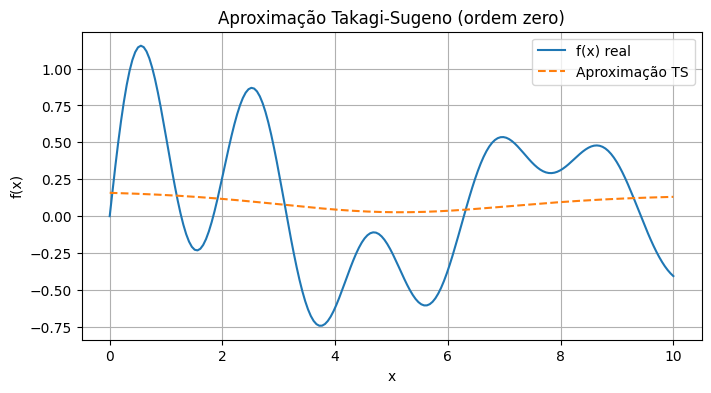

In [42]:
# Inferência Takagi-Sugeno (ordem zero)
def ts_zero(x, mus, consequentes):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, c in zip(mus, consequentes):
        num += mu * c
        den += mu
    return num / (den + 1e-8)

fx_aprox = ts_zero(x, mus, consequentes)

# Visualizando a aproximação
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real')
plt.plot(x, fx_aprox, '--', label='Aproximação TS')
plt.title('Aproximação Takagi-Sugeno (ordem zero)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## Passo 5: Avaliação do erro

Vamos calcular o erro quadrático médio (MSE) e visualizar o erro ao longo do intervalo.

MSE: 0.20946
RMSE: 0.45767


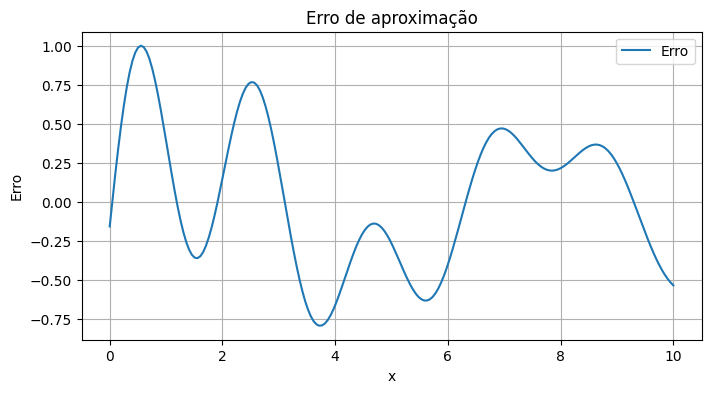

In [43]:
# Cálculo do erro
mse = np.mean((fx - fx_aprox)**2)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")

# Visualizando o erro
plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_aprox, label='Erro')
plt.title('Erro de aproximação')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.show()

## Passo 6: Considerações

- O sistema fuzzy de Takagi-Sugeno de ordem zero foi implementado sem uso de bibliotecas específicas de fuzzy.
- As funções de pertinência gaussianas foram escolhidas para cobrir o intervalo de x.
- Os consequentes foram definidos como constantes, mas podem ser otimizados usando métodos como gradiente descendente ou RLS para melhorar a aproximação.
- O erro obtido pode ser reduzido aumentando o número de regras ou ajustando os parâmetros das funções de pertinência.

## Passo 2.1: Variáveis linguísticas e funções de pertinência

- **Variável linguística de entrada:** x (intervalo [0, 10])
- **Termos linguísticos:** Baixo, Médio, Alto
- **Funções de pertinência:** Gaussianas, centradas em 2 (Baixo), 5 (Médio) e 8 (Alto), todas com sigma = 2.

Essas funções de pertinência cobrem todo o intervalo de x, permitindo que cada valor de x ative pelo menos uma regra fuzzy.

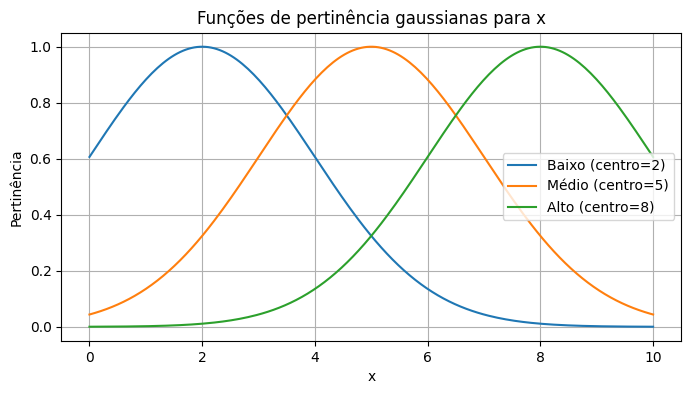

In [44]:
# Visualização das funções de pertinência e seus termos linguísticos
plt.figure(figsize=(8,4))
plt.plot(x, mus[0], label='Baixo (centro=2)')
plt.plot(x, mus[1], label='Médio (centro=5)')
plt.plot(x, mus[2], label='Alto (centro=8)')
plt.title('Funções de pertinência gaussianas para x')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os

def save_fig_img(fig, filename):
    img_dir = "img"
    if not os.path.exists(img_dir):
        os.makedirs(img_dir)
    # Não apaga nem reescreve a pasta se já existir
    path = os.path.join(img_dir, filename)
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f"Gráfico salvo em: {path}")

# Exemplo de uso para salvar um gráfico:
# fig = plt.figure()
# ... plot ...
# save_fig_img(fig, "nome_do_arquivo.png")

# Para salvar os gráficos já existentes, substitua plt.show() por:
# fig = plt.gcf()
# save_fig_img(fig, "nome_do_arquivo.png")
# plt.show()